In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import io
import os
import re
import string
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import (
    Embedding, Input, LSTM, Conv2D, Softmax, Dropout, GRU, MaxPool2D, LayerNormalization, Reshape, 
    BatchNormalization, Bidirectional
)
from tensorflow.keras.optimizers import Adam

In [1]:
!wget https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2

--2026-08-01 10:53:40--  https://data.keithito.com/data/speech/LJSpeech-1.1.tar.bz2
Resolving data.keithito.com (data.keithito.com)... 143.244.49.183, 2400:52e0:1a01::912:1
Connecting to data.keithito.com (data.keithito.com)|143.244.49.183|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2748572632 (2.6G) [text/plain]
Saving to: ‘LJSpeech-1.1.tar.bz2’

LJSpeech-1.1.tar.bz 100%[===================>]   2.56G   123MB/s    in 21s     

2026-08-01 10:54:01 (128 MB/s) - ‘LJSpeech-1.1.tar.bz2’ saved [2748572632/2748572632]



In [8]:
!mkdir "/content/dataset/"

In [9]:
!tar -xjvf "/content/LJSpeech-1.1.tar.bz2" -C "/content/dataset/"

LJSpeech-1.1/
LJSpeech-1.1/metadata.csv
LJSpeech-1.1/wavs/
LJSpeech-1.1/wavs/LJ007-0048.wav
LJSpeech-1.1/wavs/LJ041-0060.wav
LJSpeech-1.1/wavs/LJ005-0133.wav
LJSpeech-1.1/wavs/LJ039-0220.wav
LJSpeech-1.1/wavs/LJ048-0274.wav
LJSpeech-1.1/wavs/LJ036-0043.wav
LJSpeech-1.1/wavs/LJ037-0129.wav
LJSpeech-1.1/wavs/LJ011-0265.wav
LJSpeech-1.1/wavs/LJ028-0418.wav
LJSpeech-1.1/wavs/LJ042-0116.wav
LJSpeech-1.1/wavs/LJ005-0143.wav
LJSpeech-1.1/wavs/LJ035-0083.wav
LJSpeech-1.1/wavs/LJ025-0004.wav
LJSpeech-1.1/wavs/LJ013-0181.wav
LJSpeech-1.1/wavs/LJ035-0056.wav
LJSpeech-1.1/wavs/LJ029-0053.wav
LJSpeech-1.1/wavs/LJ018-0004.wav
LJSpeech-1.1/wavs/LJ029-0180.wav
LJSpeech-1.1/wavs/LJ018-0237.wav
LJSpeech-1.1/wavs/LJ015-0136.wav
LJSpeech-1.1/wavs/LJ049-0208.wav
LJSpeech-1.1/wavs/LJ004-0026.wav
LJSpeech-1.1/wavs/LJ007-0009.wav
LJSpeech-1.1/wavs/LJ025-0056.wav
LJSpeech-1.1/wavs/LJ004-0130.wav
LJSpeech-1.1/wavs/LJ032-0015.wav
LJSpeech-1.1/wavs/LJ007-0158.wav
LJSpeech-1.1/wavs/LJ010-0029.wav
LJSpeech-1.1/wavs

In [24]:
BATCH_SIZE=32
LR=1e-4
FRAME_LENGTH=255
FRAME_STEP=128
N_EPOCHS=100

### Data Visualization

In [12]:
audio_binary = tf.io.read_file("/content/dataset/LJSpeech-1.1/wavs/LJ001-0001.wav")
audio,_ = tf.audio.decode_wav(audio_binary)
waveform = tf.squeeze(audio, axis=-1)
waveform = tf.cast(waveform, tf.float32)
signal = waveform
print(signal.shape)

(212893,)


(212893,)


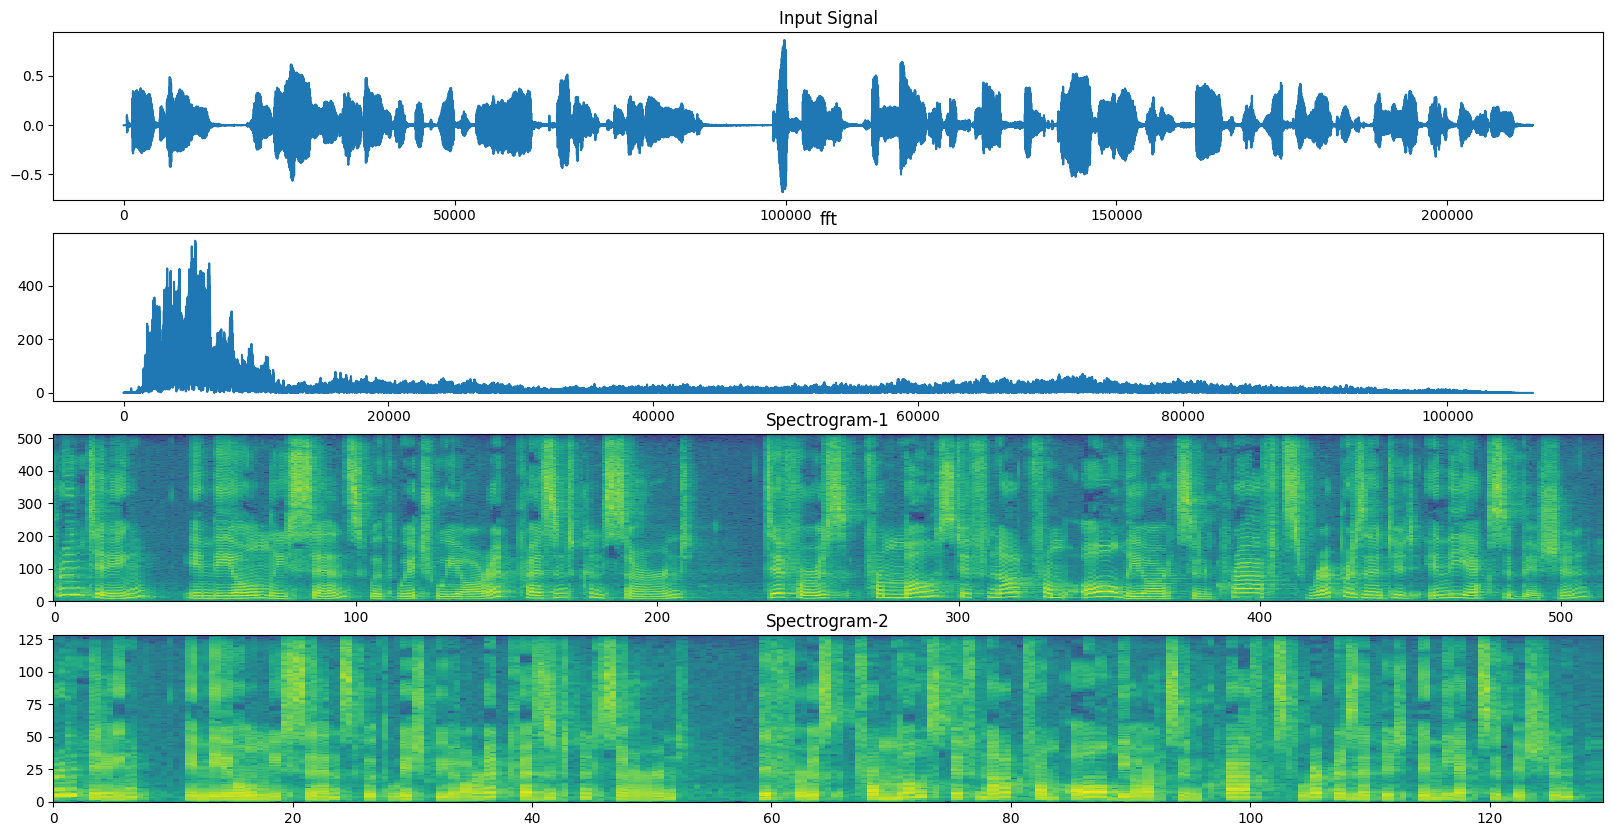

In [13]:
fig,axis=plt.subplots(4,figsize=(20,10))

L=2000
x=tf.linspace(-L//2,L//2,L)
print(signal.shape)
axis[0].plot(signal)
axis[0].set_title("Input Signal")

fft=tf.signal.rfft(signal)

axis[1].plot(tf.abs(fft))
axis[1].set_title("fft")


spec=tf.signal.stft(signal,frame_length=1024,frame_step=512,)
spec=tf.transpose(tf.abs(spec),[1,0])

power_spec=np.log(spec)
height=power_spec.shape[0]

width=power_spec.shape[1]

X=np.linspace(0,power_spec.shape[0],num=width,dtype=int)
Y=range(height)

axis[2].pcolormesh(X,Y,power_spec)
axis[2].set_title("Spectrogram-1")


spec=tf.signal.stft(signal,frame_length=256,frame_step=128, )
spec=tf.transpose(tf.abs(spec),[1,0])

power_spec=np.log(spec)
height=power_spec.shape[0]

width=power_spec.shape[1]

X=np.linspace(0,power_spec.shape[0],num=width,dtype=int)
Y=range(height)

axis[3].pcolormesh(X,Y,power_spec)
axis[3].set_title("Spectrogram-2")


plt.show()


### Data Preparation

In [14]:
audio_text = {}

In [15]:
csv_path="/content/dataset/LJSpeech-1.1/metadata.csv"
with open(csv_path, encoding="utf-8") as f:
    for line in f:
        i=line.strip().split("|")[0]
        text=line.strip().split("|")[1]
        audio_text[str(i)]=text

In [16]:
filepaths=["/content/dataset/LJSpeech-1.1/wavs/"+filename+".wav" for filename in list(audio_text.keys())]
transcriptions=[audio_text[str(filename)].lower() for filename in list(audio_text.keys())]
print(len(filepaths))
print(len(transcriptions))

13100
13100


In [17]:
dataset = tf.data.Dataset.from_tensor_slices((filepaths,transcriptions))

In [19]:
for i in dataset.take(1):
    print(i)

(<tf.Tensor: shape=(), dtype=string, numpy=b'/content/dataset/LJSpeech-1.1/wavs/LJ001-0001.wav'>, <tf.Tensor: shape=(), dtype=string, numpy=b'printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the exhibition'>)


In [20]:
def decode_audio(audio_binary):
    audio,_=tf.audio.decode_wav(audio_binary)
    return tf.squeeze(audio,axis=-1)

In [21]:
vocabulary=[""]+[chr(i) for i in range(97,97+26)]+[".",",","?"," "]
print(vocabulary)
print(len(vocabulary))

['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '.', ',', '?', ' ']
31


In [22]:
def get_label(label,):
    label=tf.strings.unicode_split(label, input_encoding="UTF-8")
    label=tf.keras.layers.StringLookup(vocabulary=vocabulary, oov_token="")(label)
    return label

In [25]:
def get_spec(filepath,label):

    audio_binary=tf.io.read_file(filepath)
    waveform=decode_audio(audio_binary)
    waveform=tf.cast(waveform,tf.float32)

    spectrogram=tf.signal.stft(
        waveform,frame_length=FRAME_LENGTH,frame_step=FRAME_STEP)
    spectrogram=tf.abs(spectrogram)
    abel=get_label(label)
    return tf.expand_dims(spectrogram,axis=-1),label

In [26]:
processed_dataset = (
    dataset.map(get_spec, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(BATCH_SIZE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)